<img src="https://raw.githubusercontent.com/PrimeReSolutions/python_actuarios/main/datos/img/logo_curso.png" width="450">

<p style="font-family: Arial; color: navy; text-align: center; font-size: 13px; letter-spacing: 1px; text-transform: uppercase; margin-bottom: 0;">
WSP — Python aplicado a modelos actuariales
</p>

<h1 style="background-color:#0070C0; color:white; text-align:center; font-family:Arial; padding:18px 0; border-radius:6px; margin-top:6px;">
📐 Sesión 3 — Triángulos e IBNR
</h1>

<div style="outline: 2px solid #EFB400; color:#000000; font-family: Arial; padding: 14px 18px; border-radius: 6px; margin-top: 14px;">
<h3 style="margin-top:0;">🎯 Objetivos de la sesión</h3>
<ul>
<li>Comprender la estructura de datos tipo <b>triángulo</b> y construirla con <code>chainladder.Triangle</code> a partir de una base en formato largo.</li>
<li>Ajustar y evaluar <b>factores de desarrollo</b> (<code>Development</code>), incluyendo la exclusión selectiva de link ratios atípicos y la incorporación de un <b>factor cola</b>.</li>
<li>Estimar el <b>IBNR</b> con los métodos determinísticos <b>Chain Ladder</b>, <b>Expected Claims</b> y <b>Bornhuetter-Ferguson</b>, y compararlos.</li>
<li>Estimar el IBNR con un método <b>estocástico</b> (Bootstrap ODP) y calcular medidas de dispersión (desviación estándar, percentil 99).</li>
<li>Aplicar todo lo anterior de manera autónoma en una <b>práctica guiada</b> con una base de siniestros distinta.</li>
</ul>
</div>

<div style="outline: 2px solid #0070C0; color:#000000; font-family: Arial; padding: 14px 18px; border-radius: 6px; margin-top: 12px;">
<h3 style="margin-top:0;">✍️ Cómo usar este notebook</h3>
<p>Los huecos que debes completar están marcados con <code>***</code>. Reemplázalos por el código o valor correspondiente y ejecuta la celda. El notebook <b>solucionario</b> (<code>solucionarios/sesion_03_triangulos_ibnr_solucionario.ipynb</code>) tiene la respuesta completa de cada <code>***</code>, con la misma estructura de celdas que este notebook. Ejecuta las celdas en orden: varias reutilizan variables definidas en celdas anteriores. La función auxiliar <code>triangulo_desde_excel</code> se explica aparte, en <code>anexos/anexo_triangulo_desde_excel.ipynb</code>; no es necesaria para completar esta sesión.</p>
</div>

### ⚙️ Celda de arranque

Si trabajas en **Google Colab**, ejecuta esta celda **antes que cualquier otra**: descarga los datos del curso desde GitHub y deja el notebook listo para leerlos. Vuelve a ejecutarla cada vez que Colab reinicie el entorno. En tu PC (instalación local) no hace nada.

In [ ]:
# ⚙️ Celda de arranque: prepara el entorno en Google Colab (en tu PC no hace nada)
import os, sys

if "google.colab" in sys.modules:
    if not os.path.exists("/content/python_actuarios"):
        !git clone -q --depth 1 https://github.com/PrimeReSolutions/python_actuarios.git /content/python_actuarios
    !pip install -q chainladder==0.8.24 sparse==0.14.0
    %cd /content/python_actuarios/notebooks

In [ ]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import chainladder as cl

DATOS = Path("../datos") if Path("../datos").exists() else Path("datos")

# Opciones de visualización
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:,.2f}".format)

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("chainladder:", cl.__version__)

---
# ⛓️ 1. El objeto `Triangle`

> Para revisar la documentación disponible visite el siguiente enlace: [ChainLadder Library](https://chainladder-python.readthedocs.io/en/latest/intro.html)

---

## 1.1 ¿Qué es un `Triangle`?

> El objeto `Triangle` es la estructura fundamental en la biblioteca `chainladder`.

---
### 🧩 ¿Qué es un `Triangle`?

Un **triángulo actuarial** es una forma tabular donde los valores observados (por ejemplo, siniestros pagados o reportados) están organizados según dos dimensiones:

- **Accident Period (fila):** el período en el que ocurrió el siniestro.
- **Development Period (columna):** el número de períodos transcurridos desde el accidente.

El objeto `Triangle` extiende esta idea, incorporando una estructura tipo `pandas.DataFrame`, pero con **propiedades y métodos especializados** para análisis actuarial.

---
## 1.2 Pasos para construir un `Triangle`
---

Para construir un triángulo en `chainladder`, partimos de un conjunto de datos tabular que contenga la información de **ocurrencia**, **desarrollo** y **valor**.

#### Pasos para la creación del triángulo

1. **Partir desde un `DataFrame` de pandas.**
   El punto de partida suele ser una tabla con información histórica de siniestros.

2. **Asegurar el formato *largo* (`long format`).**
   Cada fila debe representar una combinación de *año de ocurrencia* y *año de desarrollo*, con su respectivo valor.
   > Ejemplo de columnas requeridas: `origin`, `development`, `value`

3. **Verificar el formato de fechas o períodos.**
   Las columnas `origin` y `development` deben estar correctamente tipadas (`datetime` o `int`).
   Esto garantiza que la secuencia de desarrollo se ordene adecuadamente.

4. **Confirmar que los montos estén en formato numérico.**
   La columna de valores (`value`) debe ser de tipo `float` o `int`, sin símbolos ni separadores de miles.

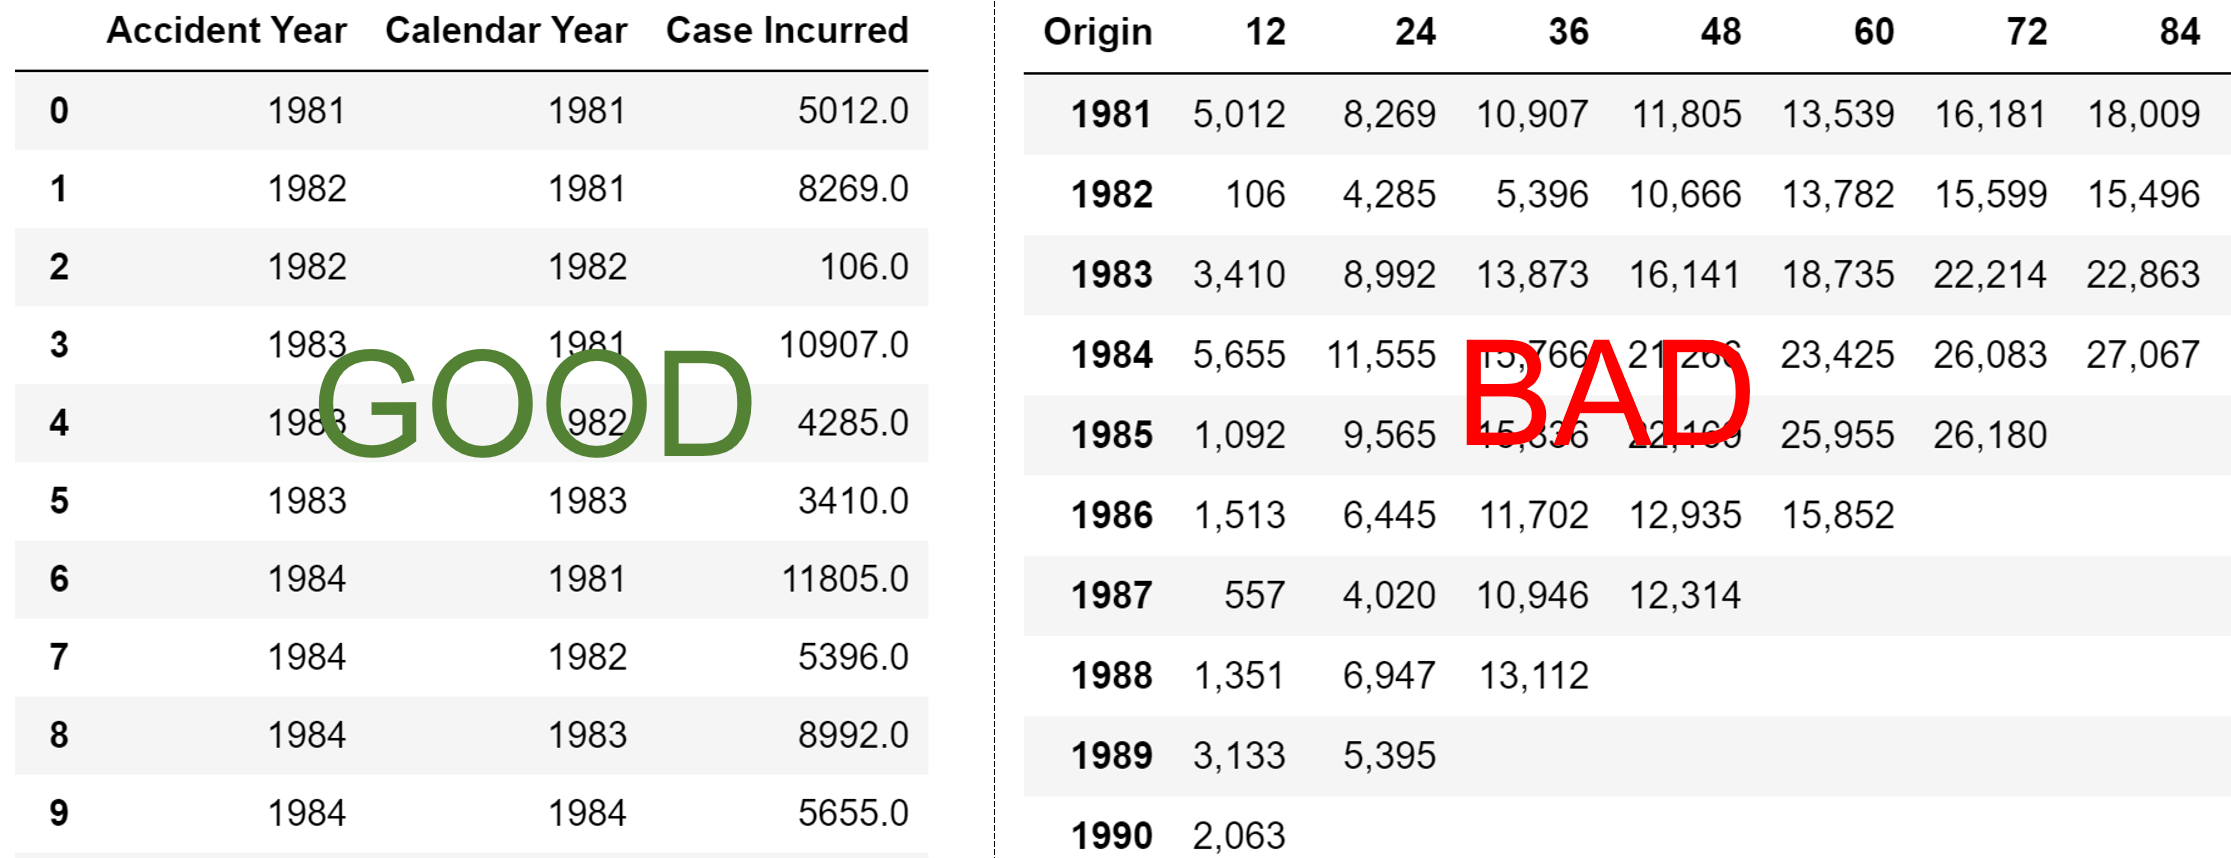

---
## 1.3 Creación del objeto `Triangle`
---

> Aqui tenemos una base de datos a nivel de movimiento, por lo tanto los montos son incrementales. Si analizamos la información tenemos los siguientes datos:

In [ ]:
prism_df = pd.read_csv(DATOS / "prism.csv")
prism_df.head()

> El trabajo inicial siempre debe ser el de identificar los datos que tenemos disponibles:

In [ ]:
# Identificar las columnas
prism_df.columns

### 1.3.1 Normalizar nombres de columnas

> Es común recibir bases con espacios sobrantes en los nombres de columnas. Antes de trabajar con ellas conviene normalizarlas.

In [ ]:
df = pd.DataFrame(
    {
        " claimNo": [1, 2],
        "AccidentDate ": ["2008-01-22", "2008-01-02"],
        " TotalPayment ": [0.0, 100.0],
        "Line": ["Home", "Home"],
        "Type": ["Dwelling", "Dwelling"],
    }
)

df.columns = df.columns.***.***()
df['claimNo']

> Hacemos una evaluación de las columnas numéricas, fechas y valores únicos:

In [ ]:
# Convertir columnas de fecha
date_cols = ["***", "***", "***", "***"]

prism_df[date_cols] = prism_df[date_cols].***(pd.to_datetime, errors='coerce')

# Máximo y mínimo para columnas numéricas
num_summary = prism_df.select_dtypes(include="***").agg(["***", "***"])

# Rango de fechas
date_ranges = {
    col: (
        prism_df[col].***().date(),
        prism_df[col].***().date()
    )
    for col in date_cols
}

# Valores únicos de Line y Type
unique_values = {
    "Line": prism_df["Line"].unique().***(),
    "Type": prism_df["Type"].unique().***()
}

# Mostrar resultados
print("=== Mínimos y máximos ===")
print(num_summary, "\n")

print("=== Rango de fechas ===")
for col, (min_d, max_d) in date_ranges.items():
    print(f"{col}: {min_d} → {max_d}")

print("\n=== Valores únicos ===")
for k, v in unique_values.items():
    print(f"{k}: {v}")

### 1.3.2 Sintaxis

In [ ]:
prism = cl.Triangle(
    data=***,
    origin="***",
    development="***",
    columns="***",
    cumulative=***,
)
prism

> No solo podemos trabajar con una columna a la vez. El objeto triangulo nos permite almacenar mas de una linea de negocio y mas de un tipo de movimiento.

In [ ]:
prism = cl.Triangle(
    data=prism_df,
    origin="AccidentDate",
    development="PaymentDate",
    columns=["***", "***"],
    cumulative=False,
)

prism

> Por *default* se infiere el formato de las fechas. Sin embargo, es considerado una buena práctica colocarlo de manera explícita.

In [ ]:
prism = cl.Triangle(
    data=prism_df,
    origin="AccidentDate",
    origin_format="***", # formato para el origen
    development="PaymentDate",
    development_format="***",# formato para el desarrollo
    columns=["Paid", "Incurred"],
    cumulative=False,
)

prism

> Podemos agregar la columna con la información de la línea de negocio en índice.

In [ ]:
prism = cl.Triangle(
    data=prism_df,
    origin="AccidentDate",
    origin_format="%Y-%m-%d", # formato para el origen
    development="PaymentDate",
    development_format="%Y-%m-%d",
    index=["***"], # Agregamos la columna al índice
    columns=["Paid", "Incurred"],
    cumulative=False,
)
prism

In [ ]:
# Para acceder a determinado conjunto de datos lo hacemos igual que en Pandas
prism["***"]

### 1.3.3 Granularidad y selección

> Podemos modificar la **granularidad** del triángulo, es decir, el nivel de **agrupación temporal** de los datos.
> Esto nos permite pasar desde una representación más detallada por ejemplo, **mensual** hasta una más agregada, como la **anual**, según las necesidades del análisis.

> **Nota:** al remuestrear (`grain`), `chainladder` emite un `FutureWarning` interno de pandas sobre el uso de `PeriodIndex` que no afecta el resultado; lo silenciamos puntualmente para no distraer de la lectura.

In [ ]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)  # FutureWarning interno de pandas al remuestrear, no afecta el resultado
    prism_OQDQ = prism.grain('***')
prism_OQDQ

In [ ]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    prism_OSDS = prism.grain('***')
prism_OSDS

In [ ]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    prism_OYDY = prism.grain("***")
prism_OYDY

> Seleccionar un triángulo dentro del objeto `Triangle`.

In [ ]:
prism_auto_incurred = prism_OYDY.loc["***", "***"]
prism_auto_incurred

### 1.3.4 Exportar un `Triangle` y sus límites

> Dado que el objeto `Triangle` comparte la misma estructura tabular que los **DataFrames** de *pandas*, es posible exportarlo fácilmente a formatos como **Excel** o **CSV** para su análisis o almacenamiento externo.
>
> No obstante, tal como se señala en la documentación oficial de la librería, este proceso es **unidireccional**: una vez exportado, no es posible reconstruir directamente el objeto `Triangle` a partir de un archivo Excel o CSV, ya que dichos formatos no conservan la estructura jerárquica interna de los índices (`origin`, `development`) ni los metadatos asociados al triángulo.

In [ ]:
prism_auto_incurred.***().***("")

In [ ]:
SALIDAS = DATOS.parent / "salidas"
SALIDAS.mkdir(exist_ok=True)

prism_auto_incurred.to_frame().to_excel(SALIDAS / "triangulo_prism_auto_incurred.xlsx")
SALIDAS / "triangulo_prism_auto_incurred.xlsx"

### 🔝 Un paso más allá

Parte de nuestro trabajo consistirá en **desarrollar funciones complementarias** que permitan **revertir este proceso**, o al menos **preservar la estructura interna del triángulo** al momento de exportarlo. Veamos primero qué obtenemos si simplemente releemos el Excel exportado:

In [ ]:
df_tri = pd.read_excel(SALIDAS / "triangulo_prism_auto_incurred.xlsx")
df_tri

> El Excel exportado es una tabla "plana": perdimos la noción de `origin`/`development` como ejes del triángulo. Reconstruir un `Triangle` a partir de un Excel en este formato ("ancho", *wide*) requiere una función auxiliar que reordene los datos a formato largo.
>
> 📎 Esa función, `triangulo_desde_excel`, se desarrolla y explica paso a paso en el anexo **`anexos/anexo_triangulo_desde_excel.ipynb`**. No la necesitamos para el resto de esta sesión: seguiremos trabajando directamente con el `Triangle` que ya construimos (`prism_auto_incurred`).

### 1.3.5 Triángulo de trabajo

De aquí en adelante usaremos `tri` como el triángulo de trabajo para explorar la clase `Development`.

In [ ]:
tri = prism_auto_incurred.copy()
tri

In [ ]:
tri_incremental = tri.***()
tri_incremental

In [ ]:
# [index, column, origin, valuation]
tri.***[:, 0, 1, 8]

In [ ]:
tri.***[:, 0, 9, 0] = tri.***[:, 0, 9, 0] * 1.5
tri

---
# 🔃 2. Desarrollo (`Development`)
---

## 2.1 Conceptos básicos

Antes de ajustar patrones de desarrollo, conviene entender cómo funcionan los **estimadores**, que siguen la misma lógica de la API de **Scikit-Learn**.

---

## 🧩 ¿Qué es un estimador?
Un **estimador** es cualquier objeto que **aprende a partir de datos**.
En `chainladder`, los estimadores siguen la interfaz de Scikit-Learn para asegurar un uso uniforme.

```python
estimator = Estimator(param1=1, param2=2)
estimator.fit(X=data)                     # Ajusta el modelo
estimator.fit(X=data, sample_weight=w)    # Con pesos de exposición
```

## 🔄 ¿Qué es un transformador?
Un **transformador** toma un `Triangle` y lo devuelve transformado (por ejemplo, con factores LDF o CDF).

```python
transformed = estimator.transform(data)
# o en una sola línea:
transformed = estimator.fit_transform(data)
```

## 🔮 ¿Qué es un predictor?
Un **predictor** genera nuevas proyecciones (por ejemplo, estimar siniestros futuros).

```python
pred = estimator.predict(new_data)
```

> 💡 En chainladder, todos los modelos siguen la estructura
`fit → transform → predict`

---

### 2.2 Clase `Development`

El módulo **Development** permite elegir distintos **factores de desarrollo**.

**Técnicas de promediado disponibles:**
- **Promedio simple**
- **Promedio ponderado por volumen**
- **Combinación de ambos**

**Control más fino de LDF:**
- Posibilidad de **excluir selectivamente ciertos link ratios** del cálculo de los **LDF**, para ajustar con mayor precisión la estimación.

> **Nota:** "Link ratio" = factor de desarrollo entre periodos consecutivos (p. ej., 12→24, 24→36).
> "LDF" = *Loss Development Factor* (factor acumulado de desarrollo).

---

<details>
<summary><strong>¿Cuándo excluir link ratios?</strong></summary>

- Cuando hay **anomalías** (cambios operativos, grandes siniestros, ajustes contables).
- Si un periodo no es **representativo** del patrón de largo plazo.

</details>

In [ ]:
cl.Development(average="***")

In [ ]:
len(tri.link_ratio.development)

In [ ]:
cl.Development(average=['***']*2+['***']*7)

> Selección y exclusión de factores

In [ ]:
cl.Development(
    drop_high=***,
    drop_low=***).fit(tri)

In [ ]:
cl.Development(drop_valuation='***').fit(tri)

In [ ]:
cl.Development(drop=[(***), (***)]).fit(tri)

In [ ]:
cl.Development(drop=(***, ***), drop_valuation='***').fit(tri)

In [ ]:
tri_2 = tri.copy()

dev = cl.Development(
    drop_high=[True]*5+[False]*4,
    drop_low=[True]*5+[False]*4).fit(tri)

In [ ]:
tri_2 = dev.***(tri_2)

ldf_2 = tri_2.***
ldf_2

In [ ]:
tri_1 = cl.Development().fit_transform(tri)

ldf_1 = tri_1.***
ldf_1

In [ ]:
ldf_2 - ldf_1

### 2.3 Mapas de calor

> Visualizar los link ratios como mapa de calor ayuda a detectar valores atípicos de un vistazo.

In [ ]:
tri_1.***.***()

In [ ]:
cl.Development(average="volume").fit_transform(tri).link_ratio.heatmap()

In [ ]:
cl.Development(
    drop_high=***,
    drop_low=***).fit_transform(tri).link_ratio.heatmap()

### 2.4 Factores personalizados y factor cola

> A veces conviene fijar nuestros propios factores de desarrollo (por ejemplo, factores de mercado o de un estudio previo) en lugar de estimarlos desde el triángulo.

In [ ]:
patterns={12: 1.8, 24: 0.4, 36: 0.3, 48: 0.3, 60: 0.48, 72: 0.40, 84:0.45, 96:0.50, 108:0.60}
cl.DevelopmentConstant(patterns=***, style='***').fit(tri_2).ldf_

> Cuando el desarrollo observado no llega a la última cola (*ultimate*), agregamos un **factor cola** para proyectar el desarrollo remanente.

In [ ]:
tail = cl.***(***).fit_transform(tri_2)
tail.***

---
# 💵 3. Métodos determinísticos
---

## 3.1 Preparación del triángulo de trabajo

> `AccidentDate` en la base `prism` va desde 2008-01-01 hasta 2017-12-13. Para esta sección construiremos un triángulo específico: siniestros **Incurred** de la línea **Auto**, acotados a un rango de fechas de trabajo.

In [ ]:
bd = prism_df.***()
bd.***

In [ ]:
bd.***

In [ ]:
bd["Line"].***()

In [ ]:
fecha_inicio = '2010-01-01'
fecha_fin = '2016-12-31' 

In [ ]:
bd = bd[(bd['AccidentDate'] >= fecha_inicio) & (bd['PaymentDate'] <= fecha_fin) & (bd['Line'] == 'Auto')]
bd.shape

In [ ]:
incrTri = cl.Triangle(bd,
                      origin="AccidentDate",
                      development="PaymentDate",
                      columns="Incurred",
                      cumulative = False)
incrTri

> Modificamos la granularidad del triángulo a anual, anclando el desarrollo al último período disponible (*trailing*).

In [ ]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    incrTri = incrTri.grain('OYDY', ***)
incrTri

> Mostrar la información en formato ORIGEN vs. VALUACIÓN (calendario).

In [ ]:
incrTri_val = incrTri.***()
incrTri_val

> Acumulamos el triángulo.

In [ ]:
cumTri = incrTri.***()
cumTri

In [ ]:
cumTri.***()

## 3.2 Factores de desarrollo

### Factores individuales

In [ ]:
incr_a2a = incrTri.***
incr_a2a

In [ ]:
incr_a2u = cumTri.***
incr_a2u

### Factores de desarrollo incrementales

> Visualizamos el desarrollo con un mapa de calor y comparamos contra una ventana móvil de 3 períodos (`n_periods`).

In [ ]:
cumTri.link_ratio.heatmap(cmap='cividis', axis=***)

In [ ]:
cl.Development(***).fit_transform(cumTri).link_ratio.heatmap(cmap='cividis', axis=0)

In [ ]:
dev = cl.Development(
        average="volume",
        drop_high=False,
        drop_low=False
).fit(incrTri)
dev.***

### Factores de desarrollo acumulados

In [ ]:
dev.***

In [ ]:
triangulo = dev.fit_transform(cumTri)
triangulo

## 3.3 Chain Ladder

In [ ]:
chain_ladder = cl.***().fit(***)
chain_ladder

In [ ]:
ultimate_cl = chain_ladder.***
ultimate_cl

In [ ]:
ibnr = chain_ladder.***
print("Suma del IBNR:", "{:,.1f}".format(***.sum()))
ibnr

In [ ]:
(ultimate_cl - chain_ladder.***).sum()

> El triángulo proyectado a última (`full_triangle_`) incluye tanto lo observado como lo proyectado; `full_expectation_` contiene solo la expectativa del modelo.

In [ ]:
proyectado = chain_ladder.***
proyectado

In [ ]:
descargado = chain_ladder.***
descargado

## 3.4 Expected Claims

In [ ]:
primas = np.array([
    25_000_000.0,
    26_500_000.0,
    28_000_000.0,
    29_500_000.0,
    31_000_000.0,
    32_500_000.0,
    34_000_000.0
])
primas

In [ ]:
expected_loss_apriori = chain_ladder.*** * 0 + pd.DataFrame(***)
expected_loss_apriori

In [ ]:
expected_claim = cl.ExpectedLoss(apriori=***).fit(triangulo, sample_weight=***)
ultimate_ec = expected_claim.***
ultimate_ec

In [ ]:
ibnr_ec = expected_claim.***
print("Suma del IBNR:", "{:,.1f}".format(***.sum()))
ibnr_ec

## 3.5 Bornhuetter-Ferguson

In [ ]:
bf_model = cl.BornhuetterFerguson(apriori=***)
bf_model.fit(***, sample_weight=***)

In [ ]:
ultimate_bf = bf_model.***
ultimate_bf

In [ ]:
ibnr_bf = bf_model.ibnr_
print("Suma del IBNR:", "{:,.1f}".format(ibnr_bf.sum()))
ibnr_bf

## 3.6 Comparación de métodos

> Comparamos los tres modelos ajustados: Chain Ladder (CL), Expected Claims (EC) y Bornhuetter-Ferguson (BF).

In [ ]:
bf_data = bf_model.ultimate_.to_frame(origin_as_datetime=True)
cl_data = chain_ladder.ultimate_.to_frame(origin_as_datetime=True)
ec_data = expected_claim.ultimate_.to_frame(origin_as_datetime=True)

bf_ibnr = bf_model.ibnr_.to_frame(origin_as_datetime=True)
cl_ibnr = chain_ladder.ibnr_.to_frame(origin_as_datetime=True)
ec_ibnr = expected_claim.ibnr_.to_frame(origin_as_datetime=True)

In [ ]:
bf_data.columns = ['BF Ultimate']
cl_data.columns = ['CL Ultimate']
ec_data.columns = ['EC Ultimate']
bf_ibnr.columns = ['BF IBNR']
cl_ibnr.columns = ['CL IBNR']
ec_ibnr.columns = ['EC IBNR']

bf_data.index = bf_data.index.year
cl_data.index = cl_data.index.year
ec_data.index = ec_data.index.year
bf_ibnr.index = bf_ibnr.index.year
cl_ibnr.index = cl_ibnr.index.year
ec_ibnr.index = ec_ibnr.index.year

# Combinar los DataFrames en una tabla resumen
summary_table = pd.concat([bf_data, cl_data, ec_data, bf_ibnr, cl_ibnr, ec_ibnr], axis=1)

# Calcular los totales para cada columna y añadir como última fila
totals = summary_table.sum().to_frame().T
totals.index = ['Total']
summary_table = pd.concat([summary_table, totals])
summary_table.fillna(0)

In [ ]:
from matplotlib.ticker import FuncFormatter

# --- 1) Convertir resultados a series anuales -------------------------------
bf_s = bf_model.ultimate_.to_frame(origin_as_datetime=True).squeeze("columns")
cl_s = chain_ladder.ultimate_.to_frame(origin_as_datetime=True).squeeze("columns")
ec_s = expected_claim.ultimate_.to_frame(origin_as_datetime=True).squeeze("columns")

# Índice a años calendario
bf_s.index = bf_s.index.year
cl_s.index = cl_s.index.year
ec_s.index = ec_s.index.year

# Unificar índices (por si alguna serie no cubre todo el rango)
idx = sorted(set(bf_s.index) | set(cl_s.index) | set(ec_s.index))
bf_s = bf_s.reindex(idx)
cl_s = cl_s.reindex(idx)
ec_s = ec_s.reindex(idx)

# --- 2) Graficar ------------------------------------------------------------
plt.figure(figsize=(10, 5.5))

plt.plot(idx, bf_s.values, marker="o", linewidth=2.2, label="BF", alpha=0.95)
plt.plot(idx, cl_s.values, marker="s", linewidth=2.2, label="CL", alpha=0.95)
plt.plot(idx, ec_s.values, marker="^", linewidth=2.2, label="EC", alpha=0.95)

# Grilla y márgenes
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.margins(x=0.2)

# Eje Y en millones
fmt_mill = FuncFormatter(lambda x, pos: f"{x/1e6:,.1f}M")
plt.gca().yaxis.set_major_formatter(fmt_mill)

# Títulos y etiquetas
plt.title("Ultimate por año: BF vs CL vs EC", fontsize=13, weight="bold")
plt.xlabel("Año de ocurrencia", fontsize=11)
plt.ylabel("Ultimate (millones)", fontsize=11)

# Leyenda fuera del área del gráfico
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

# Anotar último valor de cada modelo
for serie, name in [(bf_s, "BF"), (cl_s, "CL"), (ec_s, "EC")]:
    last_idx = serie.last_valid_index()
    if last_idx is not None:
        y = serie.loc[last_idx]
        plt.annotate(f"{name}: {y/1e6:,.1f}M",
                     xy=(last_idx, y),
                     xytext=(5, 0),
                     textcoords="offset points",
                     va="center",
                     fontsize=9)

plt.tight_layout()
plt.show()

---
# 🎲 4. Método estocástico (Bootstrap ODP)
---

Los métodos determinísticos entregan un único valor de IBNR. El **remuestreo Bootstrap ODP** (*Over-Dispersed Poisson*) genera muchas versiones simuladas del triángulo, ajusta Chain Ladder a cada una y así obtiene una **distribución** de posibles resultados: no solo el valor esperado, sino también su variabilidad.

### 4.1 Generar las muestras Bootstrap

In [ ]:
# Bootstrapping
samples = (
    cl.BootstrapODPSample(***).fit(***).***
)
samples

### 4.2 IBNR determinístico vs. estocástico

In [ ]:
ibnr_cl = cl.Chainladder().fit(triangulo).***.sum()
ibnr_bootstrap = cl.Chainladder().fit(samples).***.sum("origin").***()

print(
    "IBNR Chainladder determinístico:",
    f"{ibnr_cl:,.1f}"
)
print(
    "IBNR Chainladder estocástico:",
    f"{ibnr_bootstrap:,.1f}"
)
print("Diferencia en $:", f"{ibnr_cl - ibnr_bootstrap:,.1f}")
print("Diferencia %:", f"{abs(ibnr_cl - ibnr_bootstrap) / ibnr_cl * 100:,.1f}%")

### 4.3 Bornhuetter-Ferguson estocástico

In [ ]:
sample_weight = expected_loss_apriori

# Fit Bornhuetter-Ferguson to stochastically generated data
bf = cl.BornhuetterFerguson(***, apriori_sigma=***) # apriori_sigma indica que el vector de exposición es una variable aleatoria

bf.fit(samples, sample_weight=sample_weight)

### 4.4 Desviación estándar y percentil 99

In [ ]:
pd.options.display.float_format = '{:,.2f}'.format
ibnr = cl.Chainladder().fit(***).ibnr_.sum("origin")

ibnr_std = ibnr.***()
print("Standard deviation of reserve estimate: " + f"{round(ibnr_std,0):,}")
ibnr_99 = ibnr.***(q=***)
print("99th percentile of reserve estimate: " + f"{round(ibnr_99,0):,}")

---
<h1 style="background-color:#0070C0; color:white; text-align:center; font-family:Arial; padding:20px 0;">
📊 5. Práctica guiada — Estimación del IBNR
</h1>

En esta práctica aplicarás, de forma autónoma, los métodos de desarrollo de `chainladder` para estimar la **reserva de siniestros incurridos pero no reportados (IBNR)** sobre una base de datos distinta a la usada en los ejemplos anteriores.

A partir de un triángulo de siniestros acumulados, ajustarás modelos determinísticos y estocásticos con el fin de:

- Calcular los **factores de desarrollo (LDF y CDF)**.
- Obtener la **estimación total del IBNR** y comparar los resultados entre métodos.

---

In [ ]:
berqsherm_df = pd.read_csv(DATOS / "berqsherm.csv")
berqsherm_df.head()

### 🔎 5.1 Tarea 1 — Años disponibles en la base

**Objetivo.** Identificar **cuántos** y **cuáles** son los años de información disponibles en el conjunto de datos.

**Entregable.**
- Número total de años observados.
- Lista ordenada de los años disponibles (sin duplicados).

In [ ]:
berqsherm_df[***].***()

In [ ]:
berqsherm_df[***].***()

### 🧩 5.2 Tarea 2 — Construir el triángulo de **incurridos**

**Objetivo.** A partir de la base de datos, construir un **triángulo actuarial de siniestros incurridos** listo para aplicar métodos de desarrollo en `chainladder`.

**Entradas mínimas requeridas (formato largo):**
- `origin` (año/fecha de ocurrencia)
- `development` (año/fecha del período de desarrollo, o meses desde el origen)
- `value` (monto **incurrido**)

**Entregable.**
- Objeto `Triangle` con incurridos.

In [ ]:
berqsherm_tri = cl.***(
    data=***,
    origin=***,
    development=***,
    columns=***,
    cumulative=***,
)
berqsherm_tri

### 🔧 5.3 Tarea 3 — Acumular el triángulo y ajustar la ocurrencia más reciente

**Objetivo.**
Convertir el triángulo de incurridos al formato **acumulado** y realizar un ajuste puntual:
multiplicar los valores de la **ocurrencia más reciente** por un factor de **1.1** (incremento del 10%).

**Entregable.**
- Triángulo acumulado (`Triangle` o `DataFrame`).
- Triángulo ajustado con el incremento aplicado en la última ocurrencia.

---

In [ ]:
tri = berqsherm_tri
tri.iloc[***] = tri.iloc[***]
tri.iloc[:, :, -1:, :]

### 🔥 5.4 Tarea 4 — Identificación y exclusión de factores atípicos mediante mapa de calor

**Objetivo.**
Analizar visualmente los **factores de desarrollo (link ratios)** mediante un **mapa de calor**, con el propósito de identificar posibles **valores atípicos** (*outliers*) que podrían distorsionar la estimación del modelo de desarrollo.
Una vez identificados, dichos factores deberán **excluirse** del ajuste del modelo.

---

In [ ]:
tri.***.***

### 🧮 5.5 Tarea 5 — Construcción de la clase `Development` para la estimación del IBNR

**Objetivo.**
Implementar y ajustar un modelo de desarrollo basado en la clase `Development` de la biblioteca `chainladder`, con el fin de **estimar la reserva de siniestros incurridos pero no reportados (IBNR)**.

En esta etapa, usted deberá **decidir** los criterios de estimación y justificar sus elecciones técnicas.

---

In [ ]:
dev = cl.***(***).fit(***)
dev

## ⚙️ 5.6 Modelación determinística

En esta sección aplicaremos las **tres metodologías determinísticas** vistas en clase para la estimación de la **reserva IBNR**, comparando sus resultados y discutiendo sus ventajas relativas.

---

### 🎯 Objetivo
Estimar la reserva de siniestros **incurridos pero no reportados (IBNR)** utilizando los siguientes enfoques:

1. **Método Chain Ladder (CL)**
   Basado en los factores de desarrollo históricos (LDF) aplicados al triángulo acumulado.
2. **Método Expected Claims (EC)**
   Calcula el IBNR a partir de valores esperados de siniestros, sin depender de la experiencia histórica de desarrollo.
3. **Método Bornhuetter-Ferguson (BF)**
   Combina la información histórica del triángulo con una expectativa *a priori* (por ejemplo, una razón de pérdida esperada).

---

In [ ]:
cl.Development(***).fit_***(***)

### ChainLadder

---

In [ ]:
CL = cl.***().fit(***)
CL

### Expected Claim

---

In [ ]:
primas = np.array([
    250_000_000.0,
    350_500_000.0,
    550_000_000.0,
    850_000_000.0,
    1250_000_000.0,
    1500_500_000.0,
    2200_000_000.0,
    2500_000_000.0
])
primas

In [ ]:
expected_loss_apriori = CL.ultimate_ * 0 + pd.DataFrame(***)
expected_loss_apriori

In [ ]:
EC = cl.***(***).fit(***, sample_weight=***)
EC

### Bornhuetter - Ferguson

---

In [ ]:
bf_model = cl.BornhuetterFerguson(***)
bf_model.fit(***, sample_weight=***)

In [ ]:
print("CL - Suma del IBNR:", "{:,.1f}".format(CL.ibnr_.sum()))
print("EC - Suma del IBNR:", "{:,.1f}".format(EC.ibnr_.sum()))
print("BF - Suma del IBNR:", "{:,.1f}".format(bf_model.ibnr_.sum()))

### 🎲 5.7 Tarea 6 — Ajuste del modelo seleccionado a un enfoque **estocástico**

**Objetivo.**
Extender el modelo determinístico seleccionado a un **modelo estocástico**, con el fin de obtener una distribución de ultimates y calcular el **percentil 99%**.

---

In [ ]:
samples = (
    cl.***(***).fit(***).***
)
samples

In [ ]:
boot_dev = cl.***(drop_high=***, drop_low=***).fit_transform(***)
boot_cl = cl.***().fit(***)

ibnr_samples = (boot_cl.*** - tri.***).sum('origin').to_frame().values.flatten()
percentil_99_ibnr = np.percentile(ibnr_samples, ***)
print(f"IBNR percentil 99%: {percentil_99_ibnr:,.0f}")
percentil_99_ibnr

---
<h1 style="outline: 2px solid #EFB400; color: #000000; text-align: left; font-family: Arial; padding: 12px; border-radius: 6px;">
✅ Resumen de la sesión
</h1>

- El objeto `Triangle` es la estructura base para cualquier análisis de reservas: se construye desde un `DataFrame` en formato largo, admite múltiples columnas/índices y distintos niveles de granularidad (`grain`).
- La clase `Development` ajusta factores de desarrollo (LDF/CDF) a partir de link ratios, permitiendo excluir valores atípicos y agregar un factor cola.
- Los métodos **determinísticos** (Chain Ladder, Expected Claims, Bornhuetter-Ferguson) entregan un único valor de IBNR; combinan de distinta forma la experiencia histórica y una expectativa *a priori*.
- El método **estocástico** (Bootstrap ODP) entrega una distribución de resultados, permitiendo cuantificar la incertidumbre (desviación estándar, percentiles) además del valor esperado.
- En la práctica guiada aplicaste todo el flujo de manera autónoma sobre una base de datos distinta (`berqsherm`).

📎 Si necesitas reconstruir un `Triangle` desde un Excel en formato ancho, revisa el anexo `anexos/anexo_triangulo_desde_excel.ipynb`.